<a href="https://colab.research.google.com/github/NietoEmmanuel/SIMULACION-II/blob/main/MCMC_Algoritmo_de_Metropolis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MCMC. ALGORITMO DE METROPOLIS

# Pseudocódigo

**1. Inicializar**

$X_1=(X_1,X_2)$ Hacer: $t=1$


**2. Generar**

$Z_1,Z_2\sim N(0,1)$ independientemente.

Sea:
$ Z=(Z_1,Z_2) $ y $ Y=X_t+Z$

Calcular:
$\alpha=\alpha(X_t,Y)$



**3. Generar**

$U\sim U[0,1]$ Si: $U<\alpha$ Hacer $X_{t+1}=Y$

-----------------Otro caso: $X_{t+1}=X_t$

**4. Hacer**
$t=t+1$ Si $t=N$ (tamaño de la muestra): **Detener.**

------------------Otro caso:Regresar a 2

In [1]:
import random as r
import matplotlib.pyplot as plt
import numpy as np

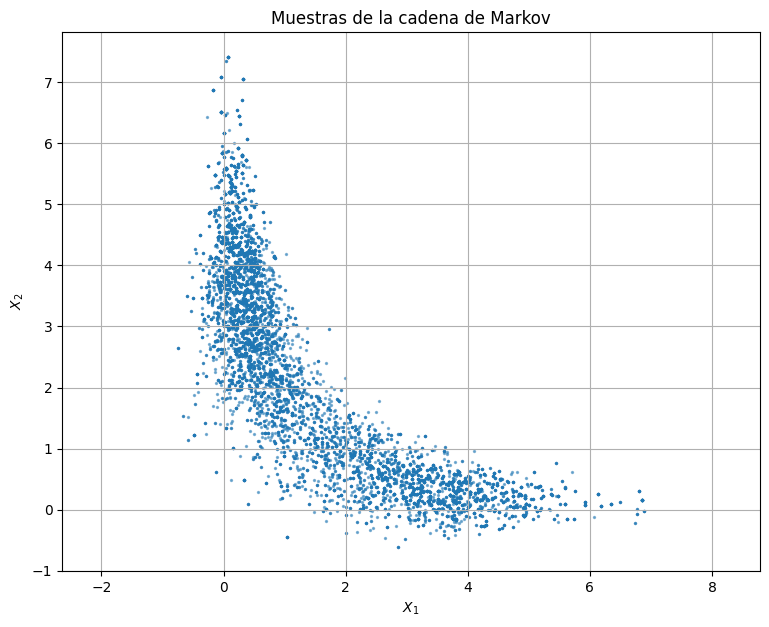

In [7]:
def funcion(x1, x2):
    exponente = -(x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2
    return (1 / 2021.6335877) * np.exp(exponente)

def caminata(x1, x2, N):

    # Inicializar X_t
    xt = (x1, x2)

    # Arreglos para guardar las muestras
    muestras_x1 = []
    muestras_x2 = []

    for t in range(N):

        # Generar Z1, Z2 ~ N(0,1)
        z1 = np.random.normal(0, 1)
        z2 = np.random.normal(0, 1)

        # Propuesta Y = X_t + Z
        Y = (xt[0] + z1, xt[1] + z2)

        # Calcular f(X_t) y f(Y)
        f_xt = funcion(xt[0], xt[1])
        f_Y = funcion(Y[0], Y[1])

        # Probabilidad de aceptación
        if f_xt == 0:
            alfa = 1.0 if f_Y > 0 else 0.0
        else:
            alfa = min(1.0, f_Y / f_xt)

        # Generar U ~ Uniforme(0,1)
        u = r.uniform(0, 1)

        # Aceptar o rechazar
        if u < alfa:
            xt = Y

        # Guardar X_t
        muestras_x1.append(xt[0])
        muestras_x2.append(xt[1])

    return np.array(muestras_x1), np.array(muestras_x2)

# Parámetros iniciales
N_muestras = 10000
x1_inicial = 0.0
x2_inicial = 0.0

m_x1, m_x2 = caminata(x1_inicial, x2_inicial, N_muestras)

#Gradicando en 2D
plt.figure(figsize=(9, 7))

plt.scatter(
    m_x1,
    m_x2,
    s=2,
    alpha=0.5
)

plt.xlabel('$X_1$')
plt.ylabel('$X_2$')

plt.title('Muestras de la cadena de Markov')

plt.grid(True)

plt.axis('equal')

plt.show()